# 20 - Survival analysis: time to readmission (Cox)
- The proper 'how soon do they return?' model - it handles patients who never return as censored, unlike the failed exact-days regression.
- Reports the C-index.
- Assumption: administrative censoring at 1 year (MIMIC dates are shifted).

In [2]:
pip install lifelines

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4118 sha256=08b4fb12595c01751099cecddf906384852696eefd3a03a6ccc806178c7a864e
  Stored in directory: /Users/robert/Library/Caches/pip/wheels/25/cc/e0/ef2969164144c899fedb22b338f6703e2b9cf46eeebf254991
Successfully built autograd-gamma
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [lifelines]━ 4/5 [lifelines]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index

DATA_DIR = "/Users/robert/Desktop/hospital-re-admission/data/processed"
RESULTS_DIR = "/Users/robert/Desktop/hospital-re-admission/notebooks/20_survival_analysis"
HORIZON = 365

## Build duration and event
Return within 1 year = event at that day; otherwise censored at 365 days.

In [5]:
df = pd.read_csv(f"{DATA_DIR}/patient_first_visit.csv")
cat_cols = ["gender", "race", "marital_status", "language", "insurance",
            "admission_type", "admission_location", "discharge_location"]
drop_cols = ["subject_id", "hadm_id", "tgt_bucket", "tgt_days", "visit_num", "split"]
features = [c for c in df.columns if c not in drop_cols]
is_train = df["split"].values == "train"

for c in cat_cols:
    m = {v: i for i, v in enumerate(sorted(df.loc[is_train, c].astype(str).unique()))}
    df[c] = df[c].astype(str).map(m).fillna(-1).astype(int)

d = df["tgt_days"]
df["duration"] = np.where(d.notna() & (d <= HORIZON), d, HORIZON).astype(float)
df["event"] = (d.notna() & (d <= HORIZON)).astype(int)
print(f"returned within 1 year (event): {df['event'].mean():.3f}   censored: {1-df['event'].mean():.3f}")

returned within 1 year (event): 0.261   censored: 0.739


## Kaplan-Meier: overall and by cancer status
How the 'not-yet-readmitted' fraction falls over the year, split by a risk factor.

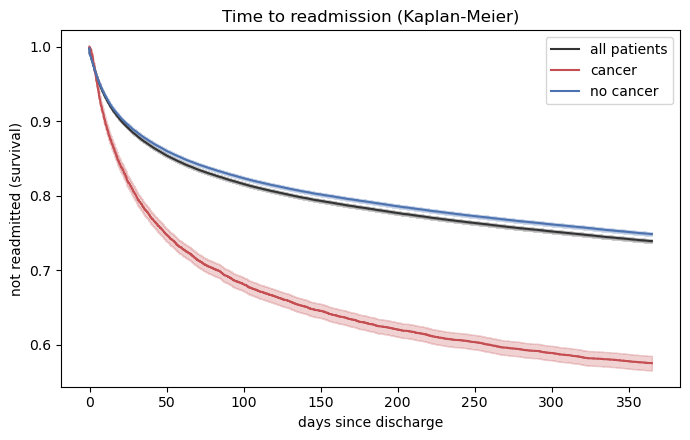

In [6]:
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(7, 4.5))
kmf.fit(df["duration"], df["event"], label="all patients")
kmf.plot_survival_function(ax=ax, color="#333333")
for val, name, col in [(1, "cancer", "#c44e52"), (0, "no cancer", "#4c72b0")]:
    m = df["cci_cancer"] == val
    kmf.fit(df.loc[m, "duration"], df.loc[m, "event"], label=name)
    kmf.plot_survival_function(ax=ax, color=col)
ax.set_xlabel("days since discharge"); ax.set_ylabel("not readmitted (survival)")
ax.set_title("Time to readmission (Kaplan-Meier)")
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/20_kaplan_meier.png", dpi=150); plt.show()

## Cox proportional-hazards model
Drop the empty-at-first-visit history flags, standardise, fit with a penalizer.
Report Harrell's C-index on the test patients.

In [7]:
std = df.loc[is_train, features].std()
keep = [c for c in features if std[c] > 1e-6]  # drops constant first-visit flags
mu, sd = df.loc[is_train, keep].mean(), df.loc[is_train, keep].std()
Z = df.copy()
for c in keep: Z[c] = (Z[c] - mu[c]) / sd[c]

train_df = Z.loc[is_train, keep + ["duration", "event"]].sample(min(60000, is_train.sum()), random_state=42)
test_df = Z.loc[~is_train, keep + ["duration", "event"]]

cph = CoxPHFitter(penalizer=0.5)
cph.fit(train_df, duration_col="duration", event_col="event")
risk = cph.predict_partial_hazard(test_df[keep])
cindex = concordance_index(test_df["duration"], -risk, test_df["event"])
print(f"Cox C-index (test): {cindex:.3f}   (0.5 = random)")

Cox C-index (test): 0.607   (0.5 = random)


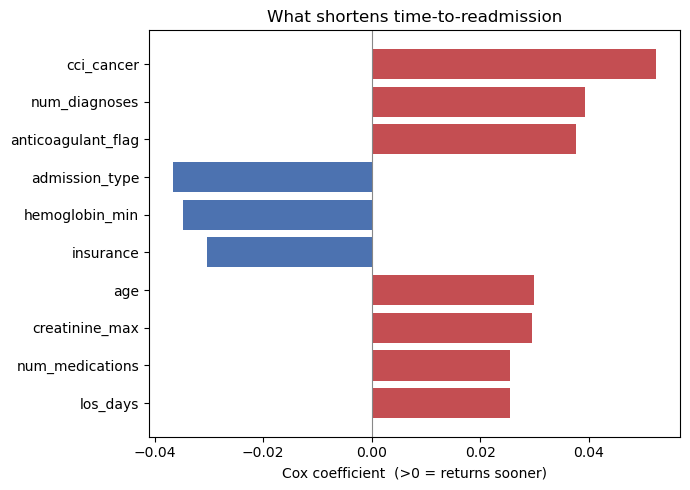

In [8]:
# Graph: strongest hazard drivers (|coefficient|).
coef = cph.summary["coef"].reindex(cph.summary["coef"].abs().sort_values().index).tail(10)
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#c44e52" if v > 0 else "#4c72b0" for v in coef.values]
ax.barh(coef.index, coef.values, color=colors)
ax.axvline(0, color="#888", linewidth=0.8)
ax.set_xlabel("Cox coefficient  (>0 = returns sooner)")
ax.set_title("What shortens time-to-readmission")
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/20_cox_coefficients.png", dpi=150); plt.show()